# EfficientNet training
This notebook trains an EfficientNet model for multi-class classification on the ERCP dataset.

In [1]:
!pip install livelossplot monai torchmetrics torchinfo timm gdown

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 627.3/627.3 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 4.7 MB/s eta 0:00:00
  Attempting uninstall: traitlets
    Found existing installation: traitlets 5.7.1
    Uninstalling traitlets-5.7.1:
      Successfully uninstalled traitlets-5.7.1
  Attempting uninstall: psutil
    Found existing installation: psutil 5.9.5
    Uninstalling psutil-5.9.5:
      Successfully uninstalled psutil-5.9.5
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
  Attempting uninstall: ipython
    Found exis

In [2]:
from livelossplot import PlotLosses
from livelossplot.outputs import MatplotlibPlot

%matplotlib inline
import matplotlib.pyplot as plt

from monai.transforms import (Activations, AsDiscrete, LoadImage, EnsureChannelFirst, Resize,
                                RandZoom, RandAdjustContrast, RandGaussianNoise, RandRotate,
                                RandGaussianSmooth, RandShiftIntensity, RandScaleIntensity,
                                ToTensor, Compose, NormalizeIntensity, Lambda)
from monai.data import decollate_batch, DataLoader
from monai.metrics import ROCAUCMetric
from monai.utils import set_determinism
from monai.config import print_config

import numpy as np

import os

from PIL import Image

import random

import seaborn as sns

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

import time

import torch
from torch.utils.data import Dataset
from torchvision.models import efficientnet_b7, EfficientNet_B7_Weights
import torch.nn as nn
from torchmetrics.classification import MulticlassF1Score
from torch.cuda.amp import autocast, GradScaler

np.random.seed(0)
set_determinism(seed=0)
print_config()

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


MONAI version: 1.5.2
Numpy version: 2.0.2
Pytorch version: 2.10.0+cu128
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /usr/local/lib/python3.12/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.4.2
scikit-image version: 0.25.2
scipy version: 1.16.3
Pillow version: 11.3.0
Tensorboard version: 2.20.0
gdown version: 5.2.2
TorchVision version: 0.25.0+cu128
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 2.2.2
einops version: 0.8.2
transformers version: 5.0.0
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/la

In [3]:
!gdown --id 1bricpHd4x8yrkGrWuiiIx3IE2TxjvHz6 -O /content/training.zip

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1bricpHd4x8yrkGrWuiiIx3IE2TxjvHz6
From (redirected): https://drive.google.com/uc?id=1bricpHd4x8yrkGrWuiiIx3IE2TxjvHz6&confirm=t&uuid=b745a5a5-bfd0-42bb-83b1-9f6f2fa40d8d
To: /content/training.zip
100% 338M/338M [00:03<00:00, 94.4MB/s]


In [4]:
!unzip training.zip -d /content/
!gdown 1MyfWztyhA3HPT9aCWGRZF8NLBypUXOK5 -O /content/models/efficientnet_b7.pth

Archive:  training.zip
   creating: /content/dataset/
  inflating: /content/dataset/README.md  
   creating: /content/dataset/test/
   creating: /content/dataset/test/Biliary_Leaks/
  inflating: /content/dataset/test/Biliary_Leaks/1391_1391_image17598.png  
  inflating: /content/dataset/test/Biliary_Leaks/1391_1391_image17600.png  
  inflating: /content/dataset/test/Biliary_Leaks/1391_1391_image17601.png  
  inflating: /content/dataset/test/Biliary_Leaks/1391_1391_image17603.png  
  inflating: /content/dataset/test/Biliary_Leaks/1391_1391_image17604.png  
  inflating: /content/dataset/test/Biliary_Leaks/1391_1391_image17606.png  
  inflating: /content/dataset/test/Biliary_Leaks/1391_1391_image17607.png  
  inflating: /content/dataset/test/Biliary_Leaks/1391_1391_image17608.png  
  inflating: /content/dataset/test/Biliary_Leaks/1391_1391_image17609.png  
  inflating: /content/dataset/test/Biliary_Leaks/1391_1391_image17611.png  
  inflating: /content/dataset/test/Biliary_Leaks/1426_1426

In [5]:
model_name = './models/efficientnet_b7.pth'

In [6]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

## Dataset
Load dataset paths and compute class counts. This section populates `data` with `train`, `val`, and `test` image file lists and their labels.

In [7]:
base_dir = './dataset'
phases = ['train', 'val', 'test']

data = {phase: {'images': [], 'labels': []} for phase in phases}
class_names = sorted([x for x in os.listdir(os.path.join(base_dir, 'train')) if os.path.isdir(os.path.join(base_dir, 'train', x))])
#class_names = sorted([x for x in os.listdir(os.path.join(base_dir, 'train')) if os.path.isdir(os.path.join(base_dir, 'train', x))])
num_class = len(class_names)

def load_images_labels(phase):
    for i, class_name in enumerate(class_names):
        class_dir = os.path.join(base_dir, phase, class_name)
        valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
        image_files = [
                            os.path.join(class_dir, x)
                            for x in os.listdir(class_dir)
                            if x.lower().endswith(valid_exts)
                        ]

        data[phase]['images'].extend(image_files)
        data[phase]['labels'].extend([i] * len(image_files))

for phase in phases:
    load_images_labels(phase)

for phase in phases:
    print(f"{phase.capitalize()} count =", len(data[phase]['images']))

Train count = 1067
Val count = 234
Test count = 267


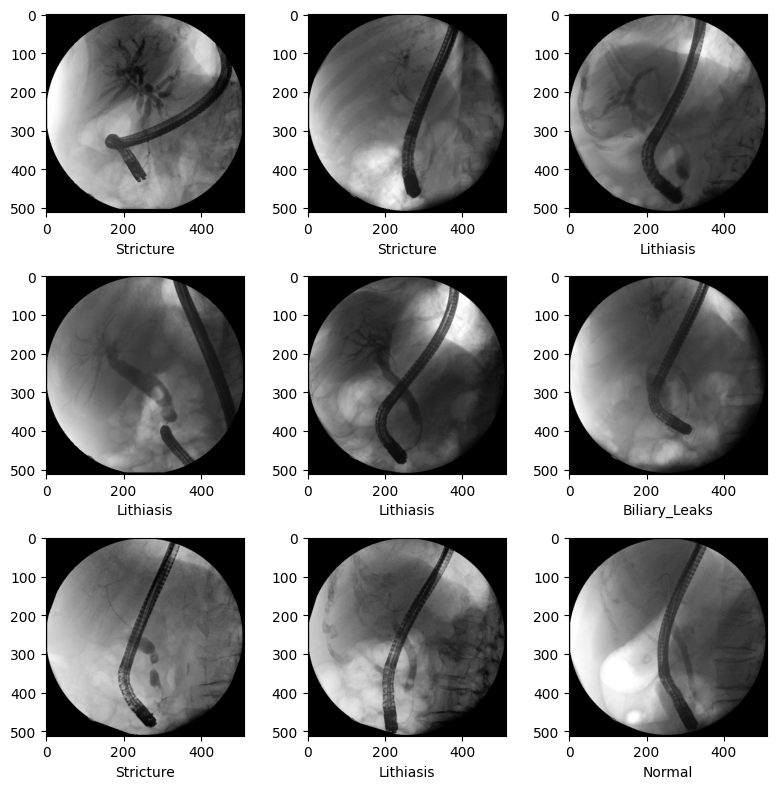

In [8]:
plt.subplots(3, 3, figsize=(8, 8))
for i, k in enumerate(np.random.randint(len(data['train']['images']), size=9)):
    im = Image.open(data['train']['images'][k])
    arr = np.array(im)
    plt.subplot(3, 3, i + 1)
    plt.xlabel(class_names[data['train']['labels'][k]])
    plt.imshow(arr, cmap='gray', vmin=0, vmax=255)
plt.tight_layout()
plt.show()

----- TRAIN CASES -----
cases: 1067
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[110 505 197 255]
1067


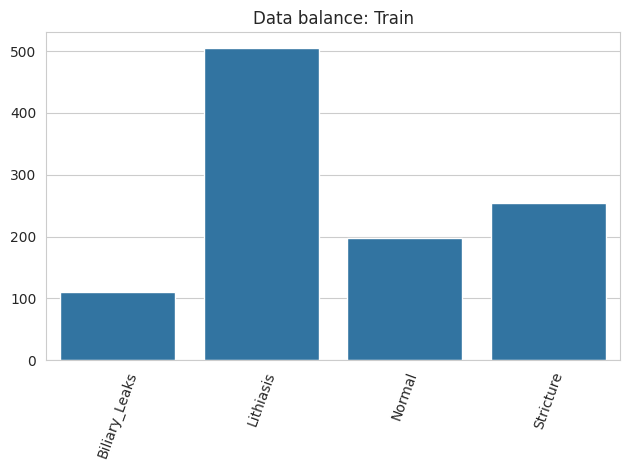

----- VALIDATION CASES -----
cases: 234
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[24 98 59 53]
234


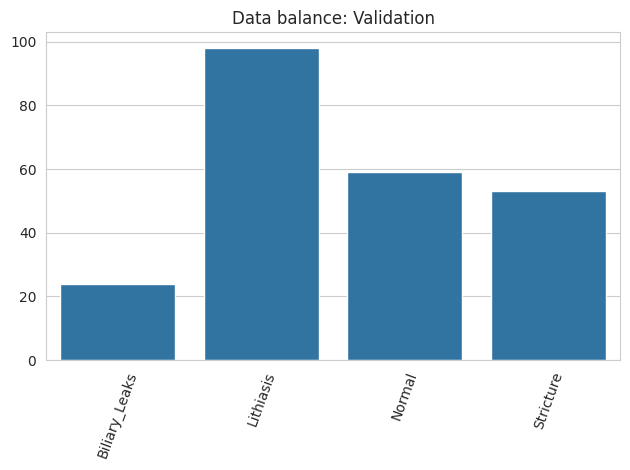

----- TEST CASES -----
cases: 267
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[ 17 123  43  84]
267


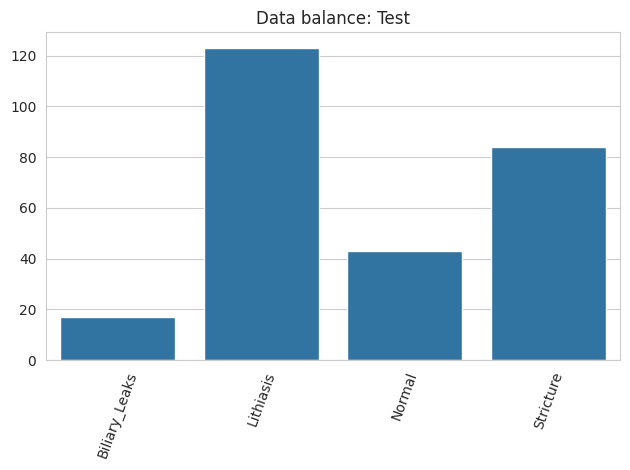

In [9]:
def visualize_holdout_balance(labels, class_names, header):
    sns.set_style('whitegrid')
    print("cases:", len(labels))
    x, y = np.unique(labels, return_counts=True)
    x_ext=[class_names[n]  for n in x]
    print(x_ext)
    print([str(n) for n in x])
    print(y)
    print(np.sum(y))
    grafico=sns.barplot(x=x_ext, y=y)
    grafico.set_title(f'Data balance: {header}')
    plt.xticks(rotation=70)
    plt.tight_layout()
    plt.show()

print("----- TRAIN CASES -----")
visualize_holdout_balance(data['train']['labels'], class_names, 'Train')
print("----- VALIDATION CASES -----")
visualize_holdout_balance(data['val']['labels'], class_names, 'Validation')
print("----- TEST CASES -----")
visualize_holdout_balance(data['test']['labels'], class_names, 'Test')


## Transforms
Define data augmentation and preprocessing for training and validation. Images are resized to 300×300.

In [10]:
import cv2

def apply_clahe(img):
    img = img.squeeze().cpu().numpy().astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)
    return torch.tensor(img, dtype=torch.float32).unsqueeze(0)

In [20]:
class EnsureSingleChannel:
    def __call__(self, img):
        if img.shape[0] == 3:
            img = img.mean(dim=0, keepdim=True)
        return img

def repeat_if_needed(img):
    if img.shape[0] == 1:
        return img.repeat(3, 1, 1)
    return img

train_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((300, 300)),
    RandRotate(range_x=15, prob=0.5),
    RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5),
    RandAdjustContrast(prob=0.5),
    RandGaussianNoise(prob=0.3, mean=0.0, std=0.01),
    RandGaussianSmooth(prob=0.3),
    RandShiftIntensity(offsets=0.1, prob=0.5),
    RandScaleIntensity(factors=0.1, prob=0.5),
    EnsureSingleChannel(), # Added to ensure single channel for CLAHE
    Lambda(apply_clahe),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

val_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((300, 300)),
    EnsureSingleChannel(), # Added to ensure single channel for CLAHE
    Lambda(apply_clahe),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

act = Activations(softmax=True)
to_onehot = AsDiscrete(to_onehot=num_class)

## Dataset & DataLoaders
Wrap file paths into a Dataset and create DataLoaders for training, validation and testing.

In [14]:
from collections import Counter

In [21]:
class MedNISTDataset(Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        image = self.image_files[index]
        return self.transforms(image), self.labels[index]

class_counts = Counter(data['train']['labels'])

weights = [
    1.0 / class_counts[label]
    for label in data['train']['labels']
]

sampler = torch.utils.data.WeightedRandomSampler(
    weights,
    num_samples=len(weights),
    replacement=True
)

train_ds = MedNISTDataset(data['train']['images'], data['train']['labels'], train_transforms)
train_loader = DataLoader(train_ds, batch_size=12, sampler=sampler, num_workers=2, pin_memory=True, persistent_workers=True)

val_ds = MedNISTDataset(data['val']['images'], data['val']['labels'], val_transforms)
val_loader = DataLoader(val_ds, batch_size=12, num_workers=2, pin_memory=True, persistent_workers=True)

test_ds = MedNISTDataset(data['test']['images'], data['test']['labels'], val_transforms)
test_loader = DataLoader(test_ds, batch_size=12, num_workers=2, pin_memory=True, persistent_workers=True)

## Model
Instantiate an EfficientNet backbone (pretrained) and adapt the classifier head to the number of classes.

In [22]:
device = torch.device("cuda:0")
weights = EfficientNet_B7_Weights.IMAGENET1K_V1
model = efficientnet_b7(weights=weights)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_class)
model = model.to(device)

## Training
The `train_model` function runs the training loop with optional early stopping, learning rate scheduling and logging of metrics (F1, AUC). Parameters and training logic are unchanged.

In [23]:

def train_model(train_dl, val_dl, model, loss_function, optimizer, epochs, name):
    early_stopping_patience = 10
    epochs_without_improvement = 0
    liveloss = PlotLosses(outputs=[MatplotlibPlot(figpath=f"{name}.png")])
    best_metric = -1
    best_metric_epoch = -1
    metric_values = list()

    # F1 metric
    f1_metric = MulticlassF1Score(num_classes=num_class, average='macro').to(device)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    scaler = torch.amp.GradScaler('cuda') # Updated to non-deprecated version

    for epoch in range(epochs):
        logs = {}
        model.train()
        epoch_loss = 0
        running_loss = 0.0
        running_corrects = 0.0
        y_pred_train = torch.tensor([], dtype=torch.float32, device=device)
        y_train = torch.tensor([], dtype=torch.long, device=device)

        for inputs, labels in train_dl:
            inputs = inputs.to(device)
            labels = labels.to(device)
            #outputs = model(inputs)
            #outputs = torch.softmax(outputs, dim=1)
            #loss = loss_function(outputs, labels)
            with torch.amp.autocast('cuda'): # Updated to non-deprecated version
              outputs = model(inputs)
              loss = loss_function(outputs, labels)
            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.detach() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)
            y_pred_train = torch.cat([y_pred_train, outputs], dim=0)
            y_train = torch.cat([y_train, labels], dim=0)

        epoch_loss = running_loss / len(train_dl.dataset)
        epoch_acc = running_corrects.float() / len(train_dl.dataset)

        # Compute F1-score on training set
        pred_train_labels = y_pred_train.argmax(dim=1)
        f1_train_value = f1_metric(pred_train_labels, y_train)

        logs['loss'] = epoch_loss.item()
        logs['accuracy'] = epoch_acc.item()
        logs['F1'] = f1_train_value.item()  # Train F1

        # Validation phase
        model.eval()
        running_loss = 0.0
        running_corrects = 0.0
        y_pred = torch.tensor([], dtype=torch.float32, device=device)
        y = torch.tensor([], dtype=torch.long, device=device)

        with torch.no_grad():
            for val_images, val_labels in val_dl:
                val_images = val_images.to(device)
                val_labels = val_labels.to(device)
                outputs = model(val_images)
                #outputs = torch.softmax(outputs, dim=1)
                loss = loss_function(outputs, val_labels)
                running_loss += loss.detach() * val_images.size(0)
                _, preds = torch.max(outputs, 1)
                running_corrects += torch.sum(preds == val_labels.data)
                y_pred = torch.cat([y_pred, outputs], dim=0)
                y = torch.cat([y, val_labels], dim=0)

            epoch_loss = running_loss / len(val_dl.dataset)
            epoch_acc = running_corrects.float() / len(val_dl.dataset)
            logs['val_loss'] = epoch_loss.item()
            logs['val_accuracy'] = epoch_acc.item()

            # Compute F1-score on validation set
            pred_labels = y_pred.argmax(dim=1)
            f1_score_value = f1_metric(pred_labels, y)
            logs['val_F1'] = f1_score_value.item()

            y_onehot = [to_onehot(i) for i in decollate_batch(y, detach=False)]
            y_pred_act = [act(i) for i in decollate_batch(y_pred)]
            auc_metric(y_pred_act, y_onehot)
            result = auc_metric.aggregate()
            auc_metric.reset()
            del y_pred_act, y_onehot
            metric_values.append(result)

            if f1_score_value > best_metric:
                best_metric = f1_score_value
                best_metric_epoch = epoch + 1
                best_train_f1 = f1_train_value.item()
                torch.save(model.state_dict(), name)
                print('saved new best metric model')
                epochs_without_improvement = 0  # reset counter
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= early_stopping_patience:
                print(
                    f"Early stopping at epoch {epoch + 1} \n"
                    f" Best Val F1: {best_metric:.4f} \n"
                    f" Best Train F1: {best_train_f1:.4f} \n"
                    f" current Val F1: {f1_score_value:.4f} \n"
                    f" current Train F1: {f1_train_value:.4f} \n"
                    f" Best epoch: {best_metric_epoch} \n"
                )
                break
            print(
                f"current epoch: {epoch + 1} current AUC: {result:.4f}"
                f" current F1 (train): {f1_train_value:.4f}"
                f" current F1 (val): {f1_score_value:.4f}"
                f" best AUC: {best_metric:.4f}"
                f" at epoch: {best_metric_epoch}"
            )

        logs['val_AUC'] = result
        liveloss.update(logs)
        liveloss.send()

        scheduler.step()

    print(f"train completed, best_metric: {best_metric:.4f} at epoch: {best_metric_epoch}")


In [24]:
model_name_classifier = './models/efficientnet_b7_classifier.pth'

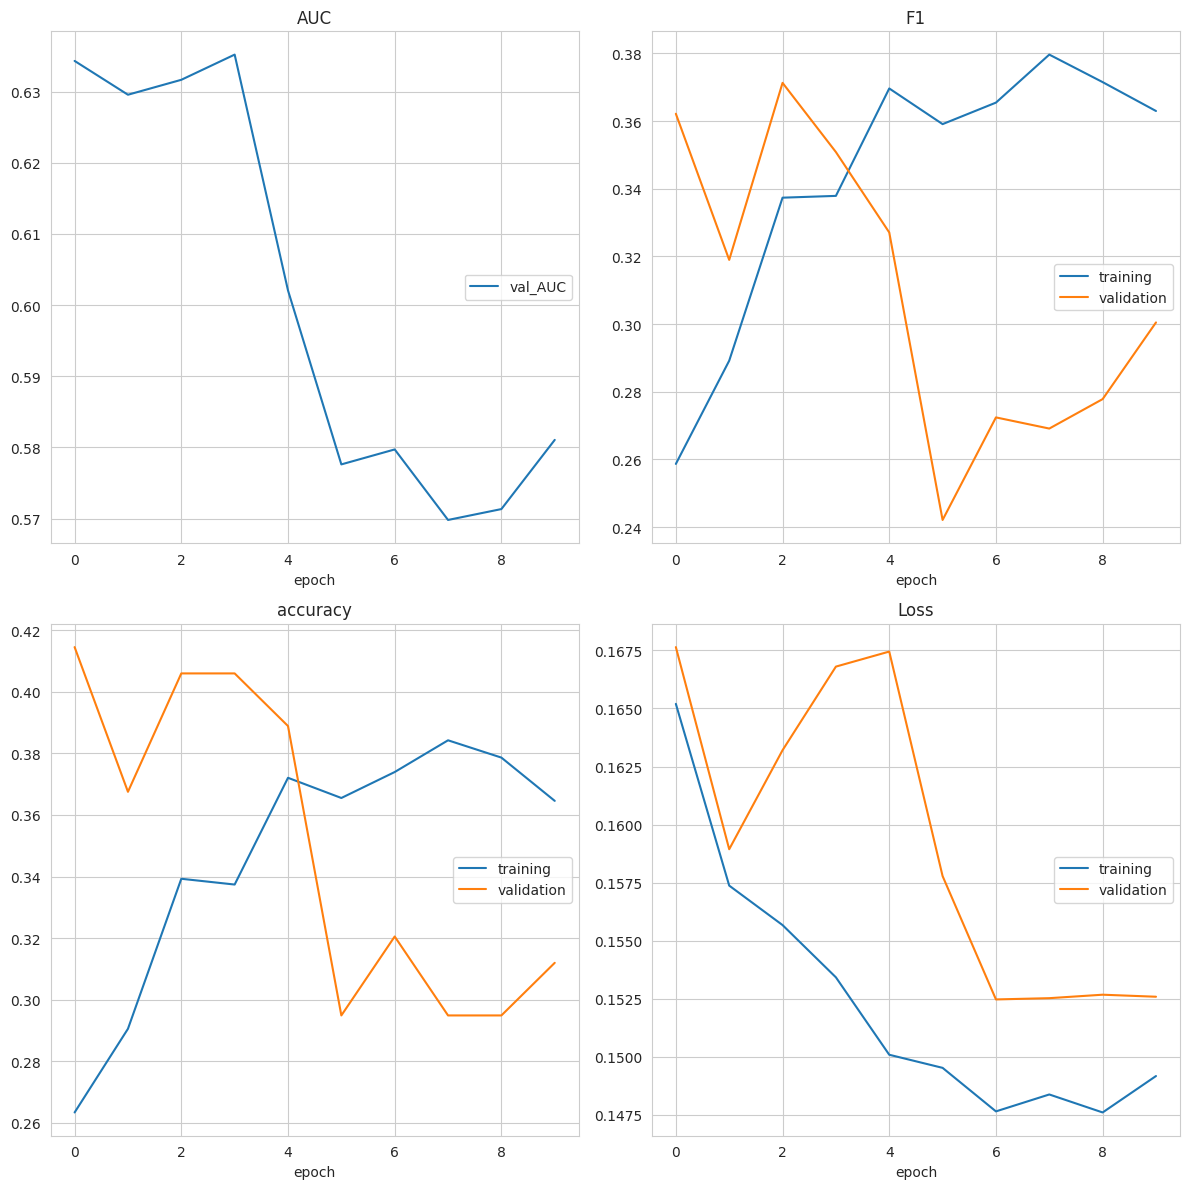

train completed, best_metric: 0.3713 at epoch: 3
Time elapsed: 536.7929239619999 seconds


In [26]:
EPOCHS_CLASSIFIER = 10
LEARNING_RATE = 1e-4

for param in model.features.parameters():
    param.requires_grad = False

from monai.losses import FocalLoss
loss_function = FocalLoss(to_onehot_y=True)

in_features = model.classifier[1].in_features

# Fix: Move the new classifier to the same device as the model
model.classifier = nn.Sequential(nn.Dropout(0.5), nn.Linear(in_features, num_class)).to(device)

optimizer = torch.optim.AdamW(model.classifier.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

val_interval = 1
auc_metric = ROCAUCMetric()

device = torch.device("cuda")
starttime = time.perf_counter()
train_model(train_loader, val_loader, model, loss_function, optimizer, EPOCHS_CLASSIFIER, model_name_classifier)
endtime = time.perf_counter()
print(f"Time elapsed: {endtime - starttime} seconds")

In [27]:
model_name_finetune = './models/efficientnet_b7_finetune.pth'

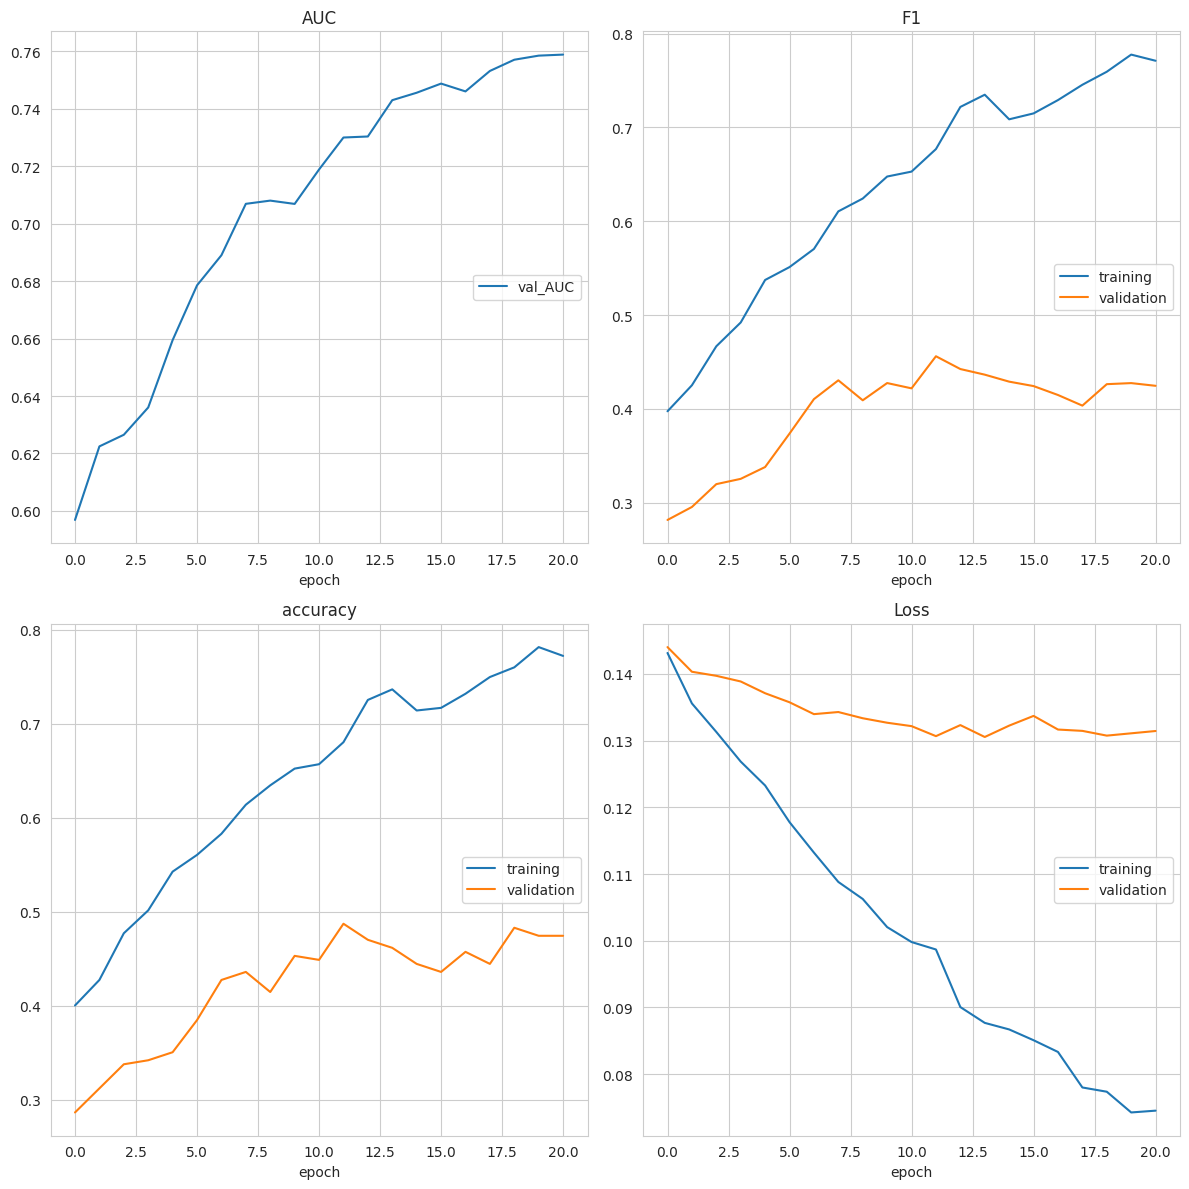

Early stopping at epoch 22 
 Best Val F1: 0.4560 
 Best Train F1: 0.6769 
 current Val F1: 0.4465 
 current Train F1: 0.7618 
 Best epoch: 12 

train completed, best_metric: 0.4560 at epoch: 12
Time elapsed: 1247.859187765 seconds


In [28]:
EPOCHS_FINE_TUNNING = 40
LEARNING_RATE = 1e-5

for param in model.features[-3:].parameters():
    param.requires_grad = True

from monai.losses import FocalLoss
loss_function = FocalLoss(to_onehot_y=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

val_interval = 1
auc_metric = ROCAUCMetric()

device = torch.device("cuda")
starttime = time.perf_counter()
train_model(train_loader, val_loader, model, loss_function, optimizer, EPOCHS_FINE_TUNNING, model_name_finetune)
endtime = time.perf_counter()
print(f"Time elapsed: {endtime - starttime} seconds")

## Evaluation
Evaluate the model on the test set, compute F1/accuracy and plot a confusion matrix. The following cells perform inference and generate the final metrics and plots.

In [ ]:
def evaluate_model(test_dl, model):
    predictions = list()
    actual_values = list()
    for inputs, labels in test_dl:
        # evaluate the model on the test set
        inputs = inputs.to(device)
        labels = labels.to(device)
        yprev = model(inputs)
        yprev = yprev.detach().cpu().numpy()
        actual = labels.cpu().numpy()
        yprev = np.argmax(yprev, axis=1)
        actual = actual.reshape((len(actual), 1))
        yprev = yprev.reshape((len(yprev), 1))
        predictions.append(yprev)
        actual_values.append(actual)
    predictions, actual_values = np.vstack(predictions), np.vstack(actual_values)

    # Compute F1-score
    f1 = f1_score(actual_values, predictions, average='macro')  # Can be 'micro', 'macro' or 'weighted'
    print(f"F1 Score: {f1:0.4f}")

    return actual_values, predictions

def display_predictions(actual_values, predictions):
    right = 0
    wrong = 0
    primeiros = 0
    i = 0
    for r, p in zip(actual_values, predictions):
        if primeiros < 20:
            print(f'true: {r} pred: {p}')
            primeiros += 1
        if r == p:
            right += 1
        else:
            wrong += 1
        i += 1
        if i > 10:
            break

    # Compute accuracy
    corrects = np.sum(predictions == actual_values)
    acc = corrects / len(test_loader.dataset)
    acc = accuracy_score(actual_values, predictions)
    print(f'Accuracy: {acc:0.3f}\n')
    print(f'correct: {right} incorrect: {wrong}')
    acc = accuracy_score(actual_values, predictions)
    print(f'Accuracy: {acc:0.3f}\n')
    print(f'correct: {right} incorrect: {wrong}')

    # Compute F1-score
    f1 = f1_score(actual_values, predictions, average='macro')
    print(f"F1 Score: {f1:0.4f}")

def display_confusion_matrix(cm, list_classes, filename):
    plt.figure(figsize=(16, 8))
    sns.heatmap(cm, annot=True, xticklabels=list_classes, yticklabels=list_classes, annot_kws={"size": 12}, fmt='g', linewidths=.5)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.savefig(f"{filename}_cm.png", dpi=300)
    plt.show()

F1 Score: 0.3047
true: [0] pred: [1]
true: [0] pred: [2]
true: [0] pred: [3]
true: [0] pred: [2]
true: [0] pred: [3]
true: [0] pred: [2]
true: [0] pred: [2]
true: [0] pred: [2]
true: [0] pred: [1]
true: [0] pred: [1]
true: [0] pred: [1]
Accuracy: 0.371

correct: 0 incorrect: 11
Accuracy: 0.371

correct: 0 incorrect: 11
F1 Score: 0.3047
               precision    recall  f1-score   support

Biliary_Leaks     0.2500    0.1765    0.2069        17
    Lithiasis     0.4923    0.5203    0.5059       123
       Normal     0.2209    0.4419    0.2946        43
    Stricture     0.3333    0.1548    0.2114        84

     accuracy                         0.3708       267
    macro avg     0.3241    0.3234    0.3047       267
 weighted avg     0.3832    0.3708    0.3602       267

[[ 3  4  8  2]
 [ 3 64 38 18]
 [ 2 16 19  6]
 [ 4 46 21 13]]


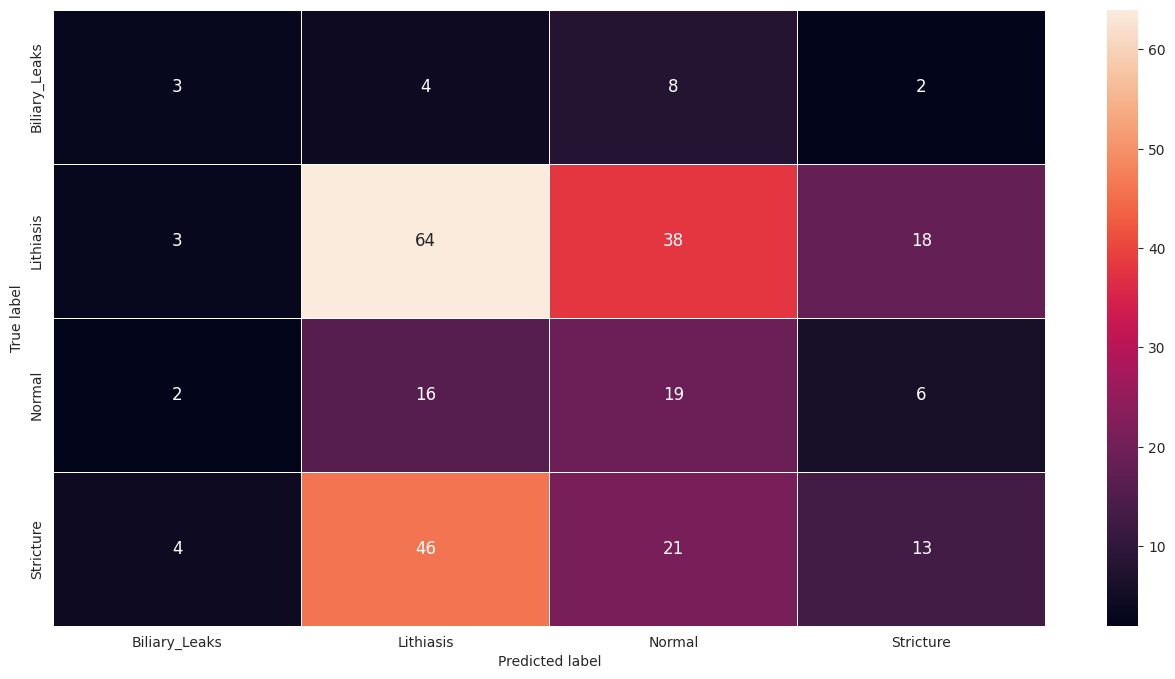

In [ ]:
# Load trained model
#model.load_state_dict(torch.load('./' + model_name))
model.load_state_dict(torch.load(model_name_classifier, map_location=device))
model.eval()

# Evaluate the model
actual_values, predictions = evaluate_model(test_loader, model)

# Display the predictions
display_predictions(actual_values, predictions)

# Classification report
print(classification_report(actual_values, predictions, target_names=class_names, digits=4, zero_division=0))

# Confusion Matrix
cr = classification_report(actual_values, predictions, target_names=class_names, output_dict=True)
list_classes = [cls for cls in cr.keys() if cls in class_names]

cm = confusion_matrix(actual_values, predictions)

print(cm)
display_confusion_matrix(cm, list_classes, model_name_classifier)

F1 Score: 0.4796
true: [0] pred: [0]
true: [0] pred: [1]
true: [0] pred: [0]
true: [0] pred: [2]
true: [0] pred: [0]
true: [0] pred: [1]
true: [0] pred: [0]
true: [0] pred: [1]
true: [0] pred: [0]
true: [0] pred: [2]
true: [0] pred: [2]
Accuracy: 0.513

correct: 5 incorrect: 6
Accuracy: 0.513

correct: 5 incorrect: 6
F1 Score: 0.4796
               precision    recall  f1-score   support

Biliary_Leaks     0.2857    0.4706    0.3556        17
    Lithiasis     0.5556    0.6098    0.5814       123
       Normal     0.5814    0.5814    0.5814        43
    Stricture     0.4754    0.3452    0.4000        84

     accuracy                         0.5131       267
    macro avg     0.4745    0.5017    0.4796       267
 weighted avg     0.5173    0.5131    0.5099       267

[[ 8  4  5  0]
 [ 6 75 13 29]
 [ 4 11 25  3]
 [10 45  0 29]]


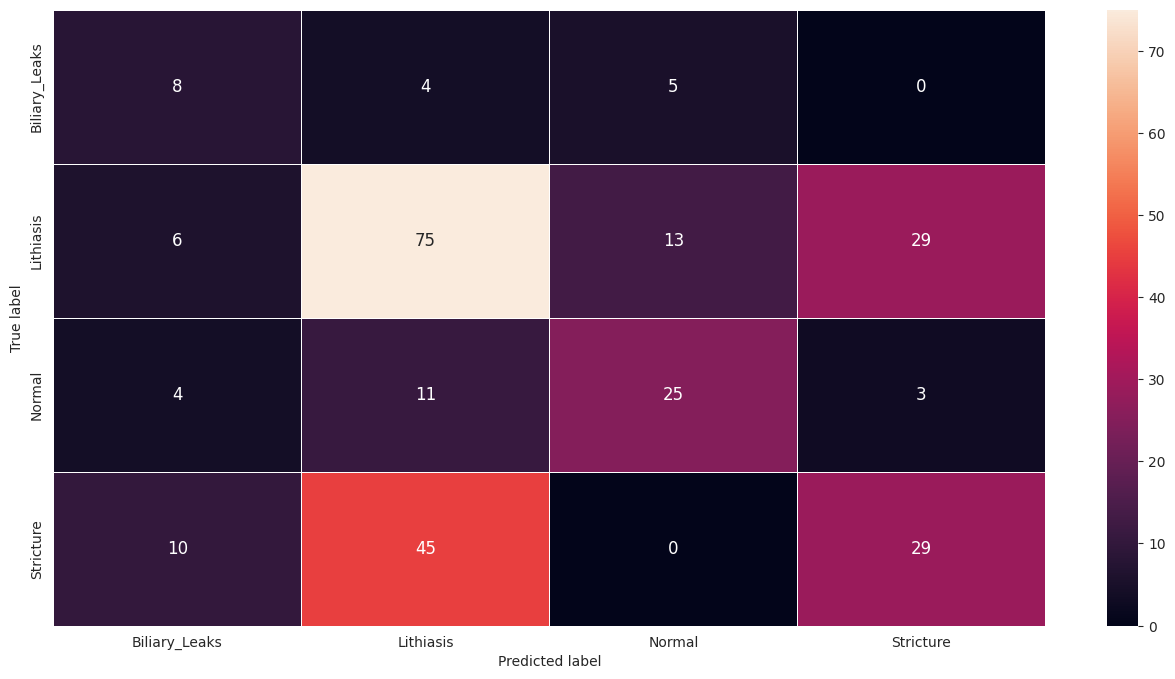

In [30]:
model.load_state_dict(torch.load(model_name_finetune, map_location=device))
model.eval()

# Evaluate the model
actual_values, predictions = evaluate_model(test_loader, model)

# Display the predictions
display_predictions(actual_values, predictions)

# Classification report
print(classification_report(actual_values, predictions, target_names=class_names, digits=4, zero_division=0))

# Confusion Matrix
cr = classification_report(actual_values, predictions, target_names=class_names, output_dict=True)
list_classes = [cls for cls in cr.keys() if cls in class_names]

cm = confusion_matrix(actual_values, predictions)

print(cm)
display_confusion_matrix(cm, list_classes, model_name_finetune)

In [31]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 106.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=59298f9a1fb90b24a3606ea2c2edcc96bb0d36c9ead804b5eaf3175c500834cb
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [32]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

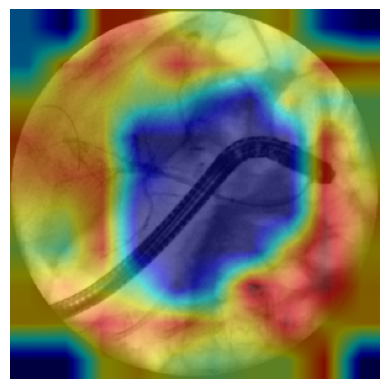

In [33]:
target_layers = [model.features[-1]]

model.eval()

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

input_tensor, label = test_ds[0]
input_tensor = input_tensor.unsqueeze(0).to(device)

grayscale_cam = cam(input_tensor=input_tensor)[0]

rgb_img = input_tensor.squeeze().permute(1,2,0).cpu().numpy()
rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

visualization = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

plt.imshow(visualization)
plt.axis('off')
plt.show()